In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

project_path = '/content/drive/MyDrive/Spacecraft-Anomaly-Detection'
results_path = project_path + '/results'
models_path = project_path + '/models'

print("Project path:", project_path)
print("Results path exists:", os.path.exists(results_path))
print("Models path exists:", os.path.exists(models_path))

Mounted at /content/drive
Project path: /content/drive/MyDrive/Spacecraft-Anomaly-Detection
Results path exists: True
Models path exists: True


#Load our time-series windows

In [2]:
sequence_path = results_path + "/time_series_windows_A8.npz"

data = np.load(sequence_path)

X_train = data["X_train"]
X_test = data["X_test"]
test_window_labels = data["test_window_labels"]
window_size = int(data["window_size"])

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Test labels shape:", test_window_labels.shape)
print("Window size:", window_size)

X_train shape: (713, 50, 1)
X_test shape: (8326, 50, 1)
Test labels shape: (8326,)
Window size: 50


#Convert data to PyTorch tensors

In [3]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

print("X_train_tensor shape:", X_train_tensor.shape)
print("X_test_tensor shape:", X_test_tensor.shape)
print("Data type:", X_train_tensor.dtype)

X_train_tensor shape: torch.Size([713, 50, 1])
X_test_tensor shape: torch.Size([8326, 50, 1])
Data type: torch.float32


#Define the LSTM Autoencoder

In [4]:
class LSTMAutoencoder(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, latent_size=16):
        super().__init__()

        self.encoder = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.encoder_fc = nn.Linear(hidden_size, latent_size)

        self.decoder_fc = nn.Linear(latent_size, hidden_size)

        self.decoder = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.output_layer = nn.Linear(hidden_size, input_size)

    def forward(self, x):
        encoded_sequence, (hidden, cell) = self.encoder(x)

        latent = self.encoder_fc(hidden[-1])

        decoder_input = self.decoder_fc(latent)
        decoder_input = decoder_input.unsqueeze(1)
        decoder_input = decoder_input.repeat(1, x.size(1), 1)

        decoded_sequence, _ = self.decoder(decoder_input)

        output = self.output_layer(decoded_sequence)

        return output


model = LSTMAutoencoder()

print(model)

LSTMAutoencoder(
  (encoder): LSTM(1, 32, batch_first=True)
  (encoder_fc): Linear(in_features=32, out_features=16, bias=True)
  (decoder_fc): Linear(in_features=16, out_features=32, bias=True)
  (decoder): LSTM(32, 32, batch_first=True)
  (output_layer): Linear(in_features=32, out_features=1, bias=True)
)


###Create the DataLoader and training setup

Now we prepare the training data and optimizer.

We will train the Autoencoder to reconstruct the training sequences:

Input sequence → LSTM Autoencoder → Reconstructed sequence

In [5]:
torch.manual_seed(42)

train_dataset = TensorDataset(X_train_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Training samples:", len(train_dataset))
print("Batch size:", 32)
print("Loss function:", criterion)
print("Optimizer:", optimizer.__class__.__name__)

Training samples: 713
Batch size: 32
Loss function: MSELoss()
Optimizer: Adam


##Train the LSTM Autoencoder

The model repeatedly sees the 713 normal training sequences and learns:

Input sequence → compress with LSTM → reconstruct the same sequence

In [6]:
num_epochs = 50
training_losses = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0

    for batch in train_loader:
        inputs = batch[0]

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = criterion(outputs, inputs)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    average_loss = epoch_loss / len(train_loader)
    training_losses.append(average_loss)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {average_loss:.6f}")

Epoch 5/50, Loss: 0.061508
Epoch 10/50, Loss: 0.051767
Epoch 15/50, Loss: 0.046525
Epoch 20/50, Loss: 0.048286
Epoch 25/50, Loss: 0.070093
Epoch 30/50, Loss: 0.028382
Epoch 35/50, Loss: 0.018350
Epoch 40/50, Loss: 0.018715
Epoch 45/50, Loss: 0.009922
Epoch 50/50, Loss: 0.006168


#Plot Training Loss

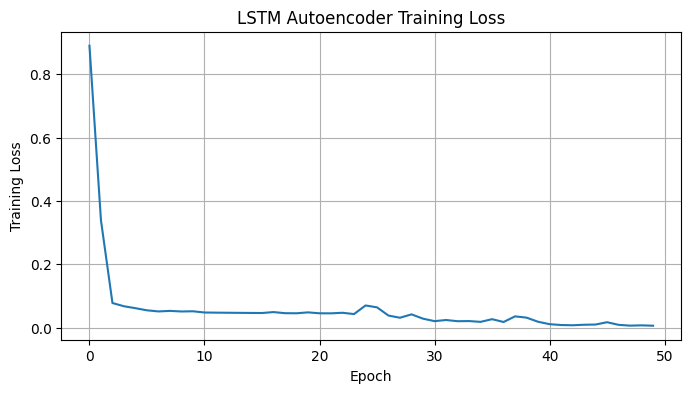

In [7]:
plt.figure(figsize=(8, 4))

plt.plot(training_losses)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("LSTM Autoencoder Training Loss")

plt.grid(True)
plt.show()

#Reconstruct Train and Test Sequences

Now we ask the trained LSTM Autoencoder to reconstruct both datasets.

In [8]:
model.eval()

with torch.no_grad():
    train_reconstructed = model(X_train_tensor)
    test_reconstructed = model(X_test_tensor)

print("Train reconstructed shape:", train_reconstructed.shape)
print("Test reconstructed shape:", test_reconstructed.shape)

Train reconstructed shape: torch.Size([713, 50, 1])
Test reconstructed shape: torch.Size([8326, 50, 1])


#Calculate Reconstruction Error

Reconstruction error = How different is the original sequence from the reconstructed sequence?

In [9]:
train_errors = torch.mean(
    (X_train_tensor - train_reconstructed) ** 2,
    dim=(1, 2)
).numpy()

test_errors = torch.mean(
    (X_test_tensor - test_reconstructed) ** 2,
    dim=(1, 2)
).numpy()

print("Train errors shape:", train_errors.shape)
print("Test errors shape:", test_errors.shape)

print("\nTraining reconstruction error:")
print("Mean:", train_errors.mean())
print("Max:", train_errors.max())

print("\nTest reconstruction error:")
print("Mean:", test_errors.mean())
print("Max:", test_errors.max())

Train errors shape: (713,)
Test errors shape: (8326,)

Training reconstruction error:
Mean: 0.006028462
Max: 0.17965534

Test reconstruction error:
Mean: 1.1909478
Max: 2.3443575


| Dataset  | Mean error | Max error |
| -------- | ---------: | --------: |
| Training |     0.0060 |    0.1797 |
| Test     |     1.1909 |    2.3444 |

The test reconstruction error is much larger than the training error. That means the LSTM Autoencoder learned the training patterns but struggles to reconstruct the unseen test sequences.

#et the Anomaly Threshold

We'll use the 99th percentile of training reconstruction error as our initial baseline, just like we did with the basic Autoencoder.

In [10]:
threshold = np.percentile(train_errors, 99)

print("LSTM Autoencoder threshold:", threshold)

y_pred_lstm = (test_errors > threshold).astype(int)

print("\nPredicted normal windows:", np.sum(y_pred_lstm == 0))
print("Predicted anomaly windows:", np.sum(y_pred_lstm == 1))

LSTM Autoencoder threshold: 0.11613635

Predicted normal windows: 2182
Predicted anomaly windows: 6144


#Evaluate the LSTM Autoencoder

This will tell us whether the LSTM Autoencoder actually improves over our previous methods.

In [11]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

y_true = test_window_labels

precision = precision_score(y_true, y_pred_lstm, zero_division=0)
recall = recall_score(y_true, y_pred_lstm, zero_division=0)
f1 = f1_score(y_true, y_pred_lstm, zero_division=0)

tn, fp, fn, tp = confusion_matrix(
    y_true,
    y_pred_lstm
).ravel()

false_positive_rate = fp / (fp + tn)
false_negative_rate = fn / (fn + tp)

print("LSTM Autoencoder Evaluation")
print("---------------------------")
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("False Positive Rate:", false_positive_rate)
print("False Negative Rate:", false_negative_rate)

print("\nConfusion Matrix:")
print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

LSTM Autoencoder Evaluation
---------------------------
Precision: 0.2775065104166667
Recall: 0.4479768786127168
F1-score: 0.342713567839196
False Positive Rate: 0.9820796460176991
False Negative Rate: 0.5520231213872833

Confusion Matrix:
TN: 81
FP: 4439
FN: 2101
TP: 1705


| Metric              |    Result |
| ------------------- | --------: |
| Precision           | **0.278** |
| Recall              | **0.448** |
| F1-score            | **0.343** |
| False Positive Rate | **0.982** |
| False Negative Rate | **0.552** |
| TN                  |        81 |
| FP                  |     4,439 |
| FN                  |     2,101 |
| TP                  |     1,705 |

The model detected about 45% of the true anomalous windows, but it also incorrectly classified about 98% of normal windows as anomalies.

So this is not a practical anomaly detector yet.

#Visualize Reconstruction Error

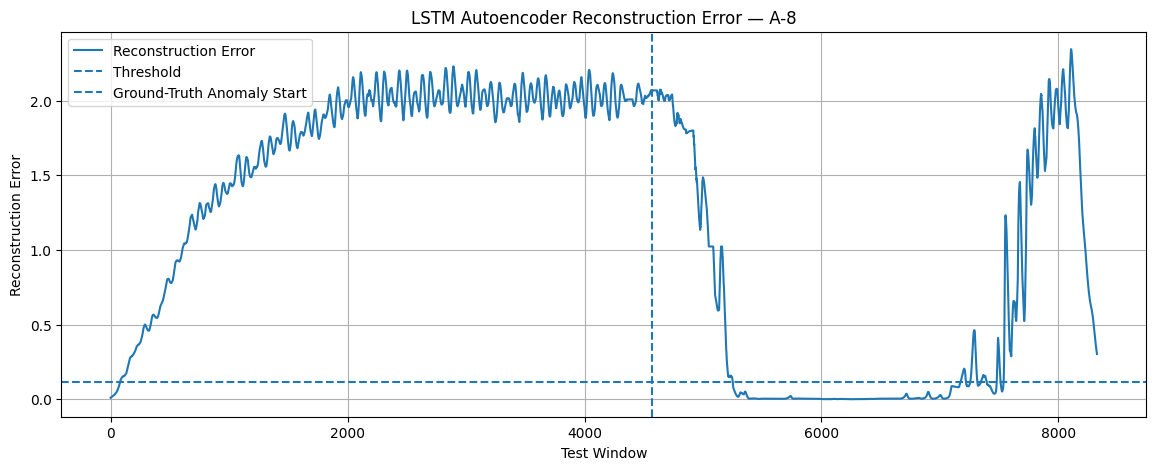

In [12]:
plt.figure(figsize=(14, 5))

plt.plot(test_errors, label="Reconstruction Error")
plt.axhline(
    threshold,
    linestyle="--",
    label="Threshold"
)

plt.axvline(
    4569,
    linestyle="--",
    label="Ground-Truth Anomaly Start"
)

plt.xlabel("Test Window")
plt.ylabel("Reconstruction Error")
plt.title("LSTM Autoencoder Reconstruction Error — A-8")

plt.legend()
plt.grid(True)
plt.show()

The graph shows an inverted anomaly response, but it does not prove that the training data was anomalous or that the labels are reversed.

#Load A-8 Training/Test Telemetry

In [14]:
data_path = project_path + '/data/raw/archive/data/data'
train_path = data_path + '/train'
test_path = data_path + '/test'

channel = "A-8"

train_A8 = np.load(train_path + "/" + channel + ".npy")
test_A8 = np.load(test_path + "/" + channel + ".npy")

train_telemetry = train_A8[:, 0]
test_telemetry = test_A8[:, 0]

print("Training telemetry shape:", train_telemetry.shape)
print("Test telemetry shape:", test_telemetry.shape)

Training telemetry shape: (762,)
Test telemetry shape: (8375,)


#Compare Training, Normal Test, and Anomaly Test

In [15]:
print("A-8 Training Statistics")
print("-----------------------")
print("Mean:", train_telemetry.mean())
print("Std:", train_telemetry.std())
print("Min:", train_telemetry.min())
print("Max:", train_telemetry.max())

normal_region = test_telemetry[:4569]
anomaly_region = test_telemetry[4569:]

print("\nA-8 Normal Test Region")
print("----------------------")
print("Mean:", normal_region.mean())
print("Std:", normal_region.std())
print("Min:", normal_region.min())
print("Max:", normal_region.max())

print("\nA-8 Anomaly Test Region")
print("-----------------------")
print("Mean:", anomaly_region.mean())
print("Std:", anomaly_region.std())
print("Min:", anomaly_region.min())
print("Max:", anomaly_region.max())

A-8 Training Statistics
-----------------------
Mean: -0.24666460299358714
Std: 0.9690446150925986
Min: -1.0
Max: 0.9999999999999996

A-8 Normal Test Region
----------------------
Mean: -0.3906871582666503
Std: 0.35705219656967024
Min: -0.6974887370630602
Max: 1.0000000000000002

A-8 Anomaly Test Region
-----------------------
Mean: -0.8162289176600386
Std: 0.24546347972239665
Min: -1.0
Max: 0.5144100293038484


| Region          |   Mean |   Std |
| --------------- | -----: | ----: |
| Training        | -0.247 | 0.969 |
| Normal test     | -0.391 | 0.357 |
| Labeled anomaly | -0.816 | 0.245 |


The training distribution is substantially different from the test distribution.

The training data has a very wide spread (std ≈ 0.969), while the normal test region is much narrower (std ≈ 0.357).

And the anomaly region is even more shifted toward negative values.

A more defensible explanation is:

The A-8 training and test distributions are substantially different, producing a strong distribution shift. The LSTM Autoencoder therefore has difficulty reconstructing the normal test regime, causing a very high false-positive rate.

#Compare the Telemetry Regions

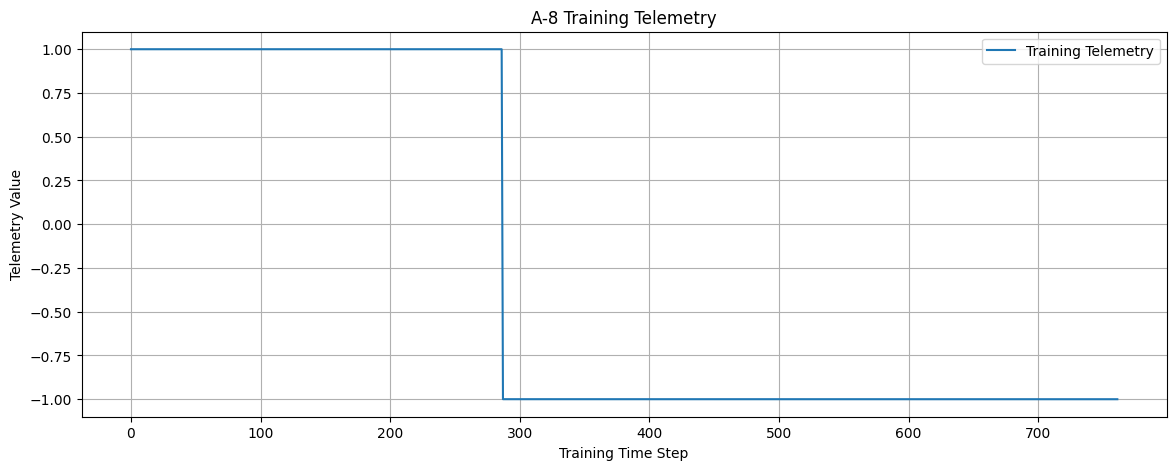

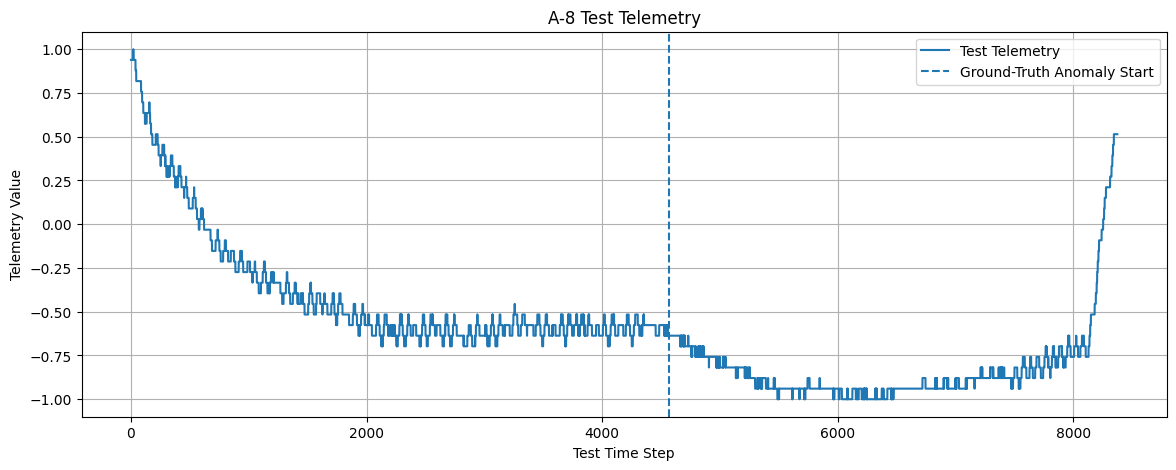

In [16]:
plt.figure(figsize=(14, 5))

plt.plot(
    train_telemetry,
    label="Training Telemetry"
)

plt.xlabel("Training Time Step")
plt.ylabel("Telemetry Value")
plt.title("A-8 Training Telemetry")

plt.grid(True)
plt.legend()
plt.show()


plt.figure(figsize=(14, 5))

plt.plot(
    test_telemetry,
    label="Test Telemetry"
)

plt.axvline(
    4569,
    linestyle="--",
    label="Ground-Truth Anomaly Start"
)

plt.xlabel("Test Time Step")
plt.ylabel("Telemetry Value")
plt.title("A-8 Test Telemetry")

plt.grid(True)
plt.legend()
plt.show()

#Check Unique Training Values

In [17]:
unique_values = np.unique(train_telemetry)

print("Number of unique training values:", len(unique_values))

print("\nFirst 20 unique values:")
print(unique_values[:20])

print("\nLast 20 unique values:")
print(unique_values[-20:])

Number of unique training values: 34

First 20 unique values:
[-1.         -0.99999376 -0.99998752 -0.99998128 -0.99997504 -0.9999688
 -0.99996256 -0.99995631 -0.99995007 -0.99994382 -0.99993758 -0.99993133
 -0.99992508 -0.99991884 -0.99991259 -0.99990634 -0.99990009 -0.99989384
 -0.99988758 -0.99988133]

Last 20 unique values:
[-0.99991259 -0.99990634 -0.99990009 -0.99989384 -0.99988758 -0.99988133
 -0.99987508 -0.99986882 -0.99986257 -0.99985631 -0.99985006 -0.9998438
 -0.99983754 -0.99983128 -0.99982502 -0.99981876 -0.9998125  -0.99980624
 -0.99979998  1.        ]


##Final A-8 conclusion

At this point, we have enough evidence to say:

The LSTM Autoencoder did not perform well on A-8. Its high false-positive rate appears strongly related to the mismatch between the highly concentrated training distribution and the broader test-time telemetry distribution. This demonstrates that reconstruction-error-based anomaly detection can confuse distribution shift with anomalies when the training data does not adequately represent normal operating behavior.

#Save LSTM Autoencoder Results

In [18]:
lstm_results = pd.DataFrame({
    "channel": ["A-8"],
    "method": ["LSTM Autoencoder"],
    "window_size": [window_size],
    "threshold_method": ["99th percentile of training reconstruction error"],
    "threshold": [threshold],
    "precision": [precision],
    "recall": [recall],
    "f1_score": [f1],
    "false_positive_rate": [false_positive_rate],
    "false_negative_rate": [false_negative_rate],
    "TN": [tn],
    "FP": [fp],
    "FN": [fn],
    "TP": [tp]
})

lstm_results_path = results_path + "/lstm_autoencoder_evaluation_A8.csv"

lstm_results.to_csv(lstm_results_path, index=False)

print(lstm_results)
print("\nSaved:", lstm_results_path)
print("File exists:", os.path.exists(lstm_results_path))

  channel            method  window_size  \
0     A-8  LSTM Autoencoder           50   

                                   threshold_method  threshold  precision  \
0  99th percentile of training reconstruction error   0.116136   0.277507   

     recall  f1_score  false_positive_rate  false_negative_rate  TN    FP  \
0  0.447977  0.342714              0.98208             0.552023  81  4439   

     FN    TP  
0  2101  1705  

Saved: /content/drive/MyDrive/Spacecraft-Anomaly-Detection/results/lstm_autoencoder_evaluation_A8.csv
File exists: True


#Save the LSTM Autoencoder

In [19]:
model_path = models_path + "/lstm_autoencoder_A8.pt"

torch.save(model.state_dict(), model_path)

print("Model saved:", model_path)
print("File exists:", os.path.exists(model_path))

Model saved: /content/drive/MyDrive/Spacecraft-Anomaly-Detection/models/lstm_autoencoder_A8.pt
File exists: True


#github commit

In [20]:
!git status --short

!git add notebooks/23_lstm_autoencoder.ipynb results/lstm_autoencoder_evaluation_A8.csv

!git commit -m "Complete SERIAL 23 LSTM Autoencoder"

!git push origin main

fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git


In [21]:
import os

project_path = "/content/drive/MyDrive/Spacecraft-Anomaly-Detection"

os.chdir(project_path)

print("Current folder:", os.getcwd())
print("Git folder exists:", os.path.exists(".git"))

Current folder: /content/drive/MyDrive/Spacecraft-Anomaly-Detection
Git folder exists: True


In [22]:
!git status --short

!git add notebooks/23_lstm_autoencoder.ipynb results/lstm_autoencoder_evaluation_A8.csv

!git commit -m "Complete SERIAL 23 LSTM Autoencoder"

!git push origin main

Refresh index: 100% (34/34), done.
 M notebooks/13_evaluate_global_zscore.ipynb
 M notebooks/14_rolling_zscore.ipynb
 M notebooks/15_compare_statistical_methods.ipynb
 M notebooks/16_isolation_forest.ipynb
 M notebooks/17_evaluate_isolation_forest.ipynb
 M notebooks/18_one_class_svm.ipynb
 M notebooks/19_compare_classical_methods.ipynb
 M notebooks/20_autoencoder.ipynb
 M notebooks/21_analyze_autoencoder.ipynb
 M notebooks/22_time_series_windows.ipynb
?? notebooks/23_lstm_autoencoder.ipynb
?? results/lstm_autoencoder_evaluation_A8.csv
Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@423ed2eed16c.(none)')
Everything up-to-date
